# 07 — Giải thích mô hình bằng SHAP

**Mục tiêu.** Mô hình bắt được 81% vụ gian lận trên tập kiểm thử. Notebook này hỏi hai câu:
*mô hình dựa vào đâu để chấm điểm* (toàn cục), và *vì sao nó sai ở những ca nó sai* (phân tích lỗi).

**Việc tương ứng:** T-32, T-33 trong [TASKS.md](../TASKS.md).

| Việc | Nội dung | Điều kiện xong |
|---|---|---|
| T-32 | SHAP toàn cục (`summary_plot` trên 2.000 mẫu) + xếp hạng `mean|SHAP|` | bảng so SHAP với xếp hạng thống kê của T-15 |
| T-33 | SHAP cho các FN điểm cao nhất và FP điểm cao nhất | nêu được mẫu hình chung + câu chốt về PCA |

**Giới hạn phải nhớ suốt notebook (04 §7).** V1–V28 là thành phần chính sau PCA của dữ liệu gốc đã
bị ẩn. Kết luận chỉ được dừng ở mức "V14 đóng góp mạnh nhất vào điểm rủi ro". Không được diễn giải
V14 thành một hành vi hay nguyên nhân nghiệp vụ.

**Sản phẩm bàn giao.** `reports/shap_ranking.csv`, `reports/error_analysis.csv` và các hình `07_*`.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score

from src import plots
from src.config import RANDOM_STATE, REPORTS_DIR
from src.data import load_prepared, split_data
from src.features import build_features
from src.modeling import build_pipeline, make_cv, oof_scores
from src.threshold import pick_threshold

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

N_TOM_TAT = 2000        # số mẫu cho summary_plot (04 §7)
N_LOI = 8               # số FN và FP điểm cao nhất đem phân tích
print(f"shap {shap.__version__}")

shap 0.52.0


---
## 1. Mô hình và ngưỡng

Cùng mô hình với notebook 06: `xgboost + class_weight`, cấu hình mặc định, huấn luyện trên toàn tập
train. τ\* chọn lại trên out-of-fold bằng đúng cách của notebook 06 (dò trên mọi điểm khác nhau),
nên notebook này chạy độc lập được.

In [2]:
df, _ = load_prepared()
X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)
X_train, X_test = build_features(X_train_tho), build_features(X_test_tho)
y_train, y_test = y_train.to_numpy(), y_test.to_numpy()
assert int(y_test.sum()) == 95

duong_dan_oof = REPORTS_DIR / "grid_results.npz"
if duong_dan_oof.exists():
    with np.load(duong_dan_oof) as npz:
        oof = npz["xgboost__class_weight"]
else:
    oof = oof_scores(build_pipeline("xgboost", "class_weight", y=y_train), X_train, y_train,
                     cv=make_cv(random_state=RANDOM_STATE))
TAU_SAO = pick_threshold(y_train, oof, "min_expected_cost", thresholds=np.unique(oof),
                         sample_fraction=len(y_train) / len(df))

mo_hinh = build_pipeline("xgboost", "class_weight", y=y_train).fit(X_train, y_train)
diem = mo_hinh.predict_proba(X_test)[:, 1]
print(f"\nPR-AUC tập kiểm thử {average_precision_score(y_test, diem):.4f}; τ* = {TAU_SAO:.5f}")

# SHAP làm việc trên đầu vào của bộ phân loại, tức SAU bước tiền xử lý (Amount đã qua RobustScaler)
tien_xu_ly, clf = mo_hinh[:-1], mo_hinh[-1]
Z_test = tien_xu_ly.transform(X_test)
DAC_TRUNG = list(Z_test.columns)
print(f"{len(DAC_TRUNG)} đặc trưng vào mô hình: {DAC_TRUNG[:3]} … {DAC_TRUNG[-2:]}")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.



PR-AUC tập kiểm thử 0.8252; τ* = 0.02317
31 đặc trưng vào mô hình: ['Amount', 'V1', 'V2'] … ['hour_sin', 'hour_cos']


---
## 2. SHAP toàn cục — T-32

`shap.TreeExplainer` tính giá trị SHAP **chính xác** cho mô hình cây, trong **không gian log-odds**:
`base_value + Σ SHAP = logit(điểm rủi ro)`. Ô dưới kiểm tra đúng đẳng thức đó trên toàn bộ tập test
trước khi tin bất kỳ con số nào.

Tính trên toàn bộ 56.746 giao dịch test (khoảng 25 giây) chứ không chỉ 2.000 mẫu, vì bảng xếp
hạng `mean|SHAP|` sẽ vào `metrics.json` và phải đại diện cho cả luồng giao dịch.

In [3]:
bat_dau = time.perf_counter()
giai_thich = shap.TreeExplainer(clf)
sv = giai_thich.shap_values(Z_test)
GOC = float(np.ravel(giai_thich.expected_value)[0])
print(f"SHAP cho {sv.shape[0]:,} × {sv.shape[1]}: {time.perf_counter() - bat_dau:.0f}s; "
      f"base value = {GOC:.3f} (logit) = xác suất {1 / (1 + np.exp(-GOC)):.3f}")

# Kiểm tra tính cộng: base + ΣSHAP phải bằng margin (logit) của chính booster
margin = clf.predict(Z_test, output_margin=True)
sai_so = np.abs(GOC + sv.sum(axis=1) - margin).max()
print(f"|base + ΣSHAP − logit| lớn nhất: {sai_so:.2e}")
assert sai_so < 1e-3, "SHAP không cộng về đúng đầu ra của mô hình"

# Base value cao (xác suất khoảng 0,96) là do scale_pos_weight = 599,5: mô hình học trên dữ liệu
# "như thể" hai lớp cân bằng. Điểm của một giao dịch hợp lệ điển hình vì thế là tổng SHAP âm lớn.
SV = pd.DataFrame(sv, columns=DAC_TRUNG)

SHAP cho 56,746 × 31: 48s; base value = 3.276 (logit) = xác suất 0.964


|base + ΣSHAP − logit| lớn nhất: 2.19e-05


C:\Users\ACER\AppData\Local\Temp\ipykernel_42272\690547307.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[mau], Z_test.iloc[mau], max_display=15, show=False, plot_size=(9, 7))


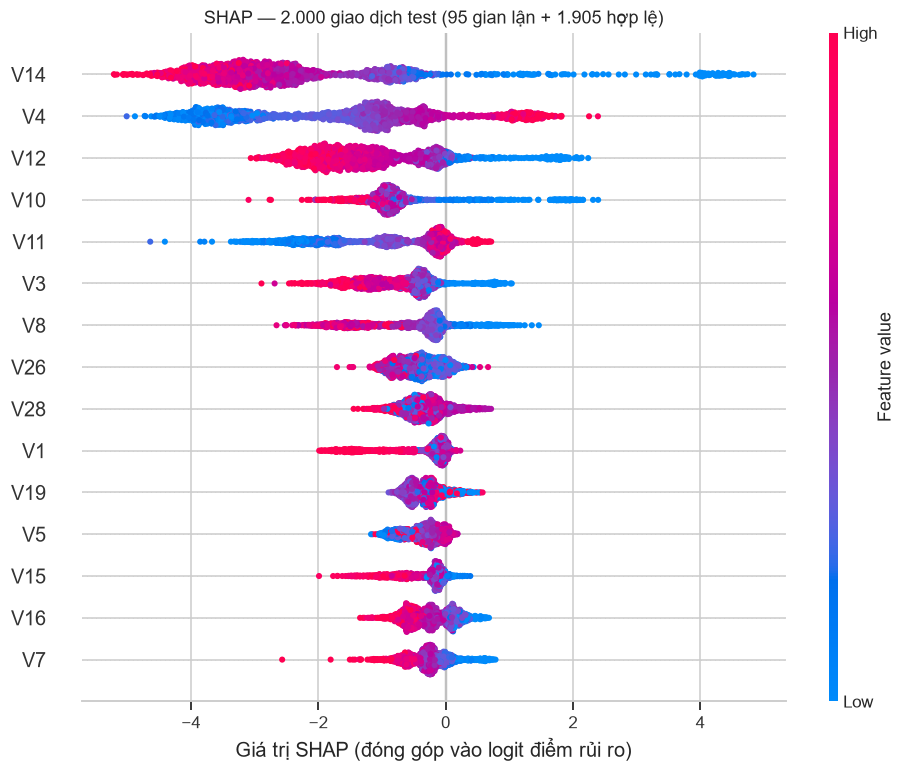

In [4]:
# Mẫu 2.000 cho summary_plot: toàn bộ 95 gian lận + 1.905 giao dịch hợp lệ ngẫu nhiên.
# Mẫu ngẫu nhiên thuần chỉ có khoảng 3 vụ gian lận, và hình sẽ chỉ kể chuyện của lớp hợp lệ.
rng = np.random.default_rng(RANDOM_STATE)
chi_so_gl = np.flatnonzero(y_test == 1)
chi_so_hl = rng.choice(np.flatnonzero(y_test == 0), size=N_TOM_TAT - chi_so_gl.size, replace=False)
mau = np.concatenate([chi_so_gl, chi_so_hl])

shap.summary_plot(sv[mau], Z_test.iloc[mau], max_display=15, show=False, plot_size=(9, 7))
fig = plt.gcf()
fig.axes[0].set_title("SHAP — 2.000 giao dịch test (95 gian lận + 1.905 hợp lệ)")
fig.axes[0].set_xlabel("Giá trị SHAP (đóng góp vào logit điểm rủi ro)")
plots.save_fig(fig, "07_shap_summary.png")
plt.show()

In [5]:
# Xếp hạng mean|SHAP| — trên toàn tập test, và riêng trong lớp gian lận
xh = pd.DataFrame({
    "mean_abs_shap": SV.abs().mean(),
    "mean_abs_shap_fraud": SV[y_test == 1].abs().mean(),
    "mean_shap_fraud": SV[y_test == 1].mean(),
}).sort_values("mean_abs_shap", ascending=False)
xh["rank_shap"] = np.arange(1, len(xh) + 1)
xh["rank_shap_fraud"] = xh["mean_abs_shap_fraud"].rank(ascending=False).astype(int)
xh["share"] = xh["mean_abs_shap"] / xh["mean_abs_shap"].sum()

# Đối chiếu 04 §7: hệ số chuẩn hoá của hồi quy logistic (class_weight) trên cùng đặc trưng
lr = build_pipeline("logistic_regression", "class_weight", y=y_train).fit(X_train, y_train)
Z_train_lr = lr[:-1].transform(X_train)
he_so = pd.Series(lr[-1].coef_[0] * Z_train_lr.std().to_numpy(), index=Z_train_lr.columns)
xh["lr_std_coef"] = he_so
xh["rank_lr"] = he_so.abs().rank(ascending=False).astype(int)

# Đối chiếu T-15: xếp hạng thống kê đơn biến (Mann–Whitney, Cohen's d, Cliff's delta, Pearson)
tk = pd.read_csv(REPORTS_DIR / "feature_ranking.csv").set_index("feature")
tk = tk[tk["in_model"]]
for cot in ("abs_cohens_d", "abs_cliffs_delta", "pearson_r"):
    xh[cot] = tk[cot]
chung = xh.dropna(subset=["abs_cohens_d"]).copy()           # 29 đặc trưng có ở cả hai bảng
for cot, ten in (("abs_cohens_d", "rank_cohens_d"), ("abs_cliffs_delta", "rank_cliffs_delta")):
    chung[ten] = chung[cot].rank(ascending=False).astype(int)
chung["rank_pearson"] = chung["pearson_r"].abs().rank(ascending=False).astype(int)
chung["rank_shap_29"] = chung["mean_abs_shap"].rank(ascending=False).astype(int)
xh = xh.join(chung[["rank_cohens_d", "rank_cliffs_delta", "rank_pearson"]])
xh.index.name = "feature"
xh.reset_index().to_csv(REPORTS_DIR / "shap_ranking.csv", index=False, encoding="utf-8")

cot_hien = ["mean_abs_shap", "share", "rank_shap", "rank_shap_fraud", "rank_lr",
            "rank_cohens_d", "rank_cliffs_delta", "rank_pearson"]
display(xh[cot_hien].head(15).style.format({"mean_abs_shap": "{:.3f}", "share": "{:.1%}",
        "rank_cohens_d": "{:.0f}", "rank_cliffs_delta": "{:.0f}", "rank_pearson": "{:.0f}"})
        .background_gradient(subset=["mean_abs_shap"], cmap="Reds"))

print("Tương quan hạng Spearman với mean|SHAP| (29 đặc trưng chung):")
for cot in ("rank_shap_fraud", "rank_lr", "rank_cohens_d", "rank_cliffs_delta", "rank_pearson"):
    rho = spearmanr(chung["rank_shap_29"], chung[cot] if cot in chung else xh.loc[chung.index, cot]).statistic
    print(f"  {cot:18s}: {rho:.3f}")
top5 = xh["share"].head(5).sum()
print(f"\n5 đặc trưng đầu chiếm {top5:.0%} tổng mean|SHAP|; "
      f"hour_sin + hour_cos: {xh.loc[['hour_sin', 'hour_cos'], 'share'].sum():.1%}, Amount: {xh.loc['Amount', 'share']:.1%}")

,mean_abs_shap,share,rank_shap,rank_shap_fraud,rank_lr,rank_cohens_d,rank_cliffs_delta,rank_pearson
feature,,,,,,,,
V14,2.679,15.8%,1,1,3,2,1,2
V4,1.878,11.1%,2,4,6,9,2,9
V12,1.292,7.6%,3,3,4,3,3,3
V11,1.002,5.9%,4,7,13,8,4,8
V10,0.946,5.6%,5,2,5,4,5,4
V3,0.857,5.1%,6,6,16,6,6,6
V8,0.668,3.9%,7,5,17,17,18,17
V26,0.472,2.8%,8,13,28,26,25,26
V1,0.407,2.4%,9,31,2,11,12,11


Tương quan hạng Spearman với mean|SHAP| (29 đặc trưng chung):
  rank_shap_fraud   : 0.619
  rank_lr           : 0.297
  rank_cohens_d     : 0.424
  rank_cliffs_delta : 0.426
  rank_pearson      : 0.424

5 đặc trưng đầu chiếm 46% tổng mean|SHAP|; hour_sin + hour_cos: 2.7%, Amount: 2.0%


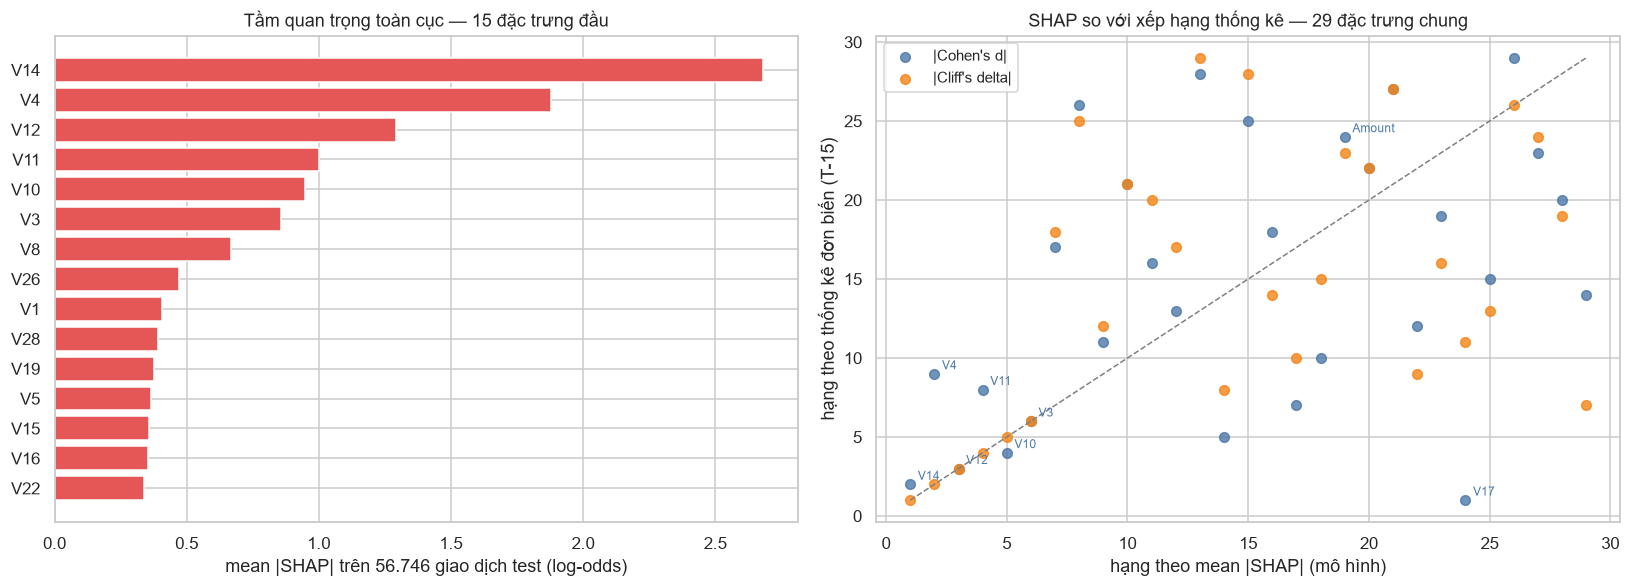

In [6]:
fig, truc = plt.subplots(1, 2, figsize=(15, 5.5))
ax = truc[0]
top = xh.head(15)
ax.barh(top.index[::-1], top["mean_abs_shap"][::-1], color="#E45756")
ax.set_xlabel("mean |SHAP| trên 56.746 giao dịch test (log-odds)")
ax.set_title("Tầm quan trọng toàn cục — 15 đặc trưng đầu")

ax = truc[1]
for cot, mau_, nhan in (("rank_cohens_d", "#4C78A8", "|Cohen's d|"),
                         ("rank_cliffs_delta", "#F58518", "|Cliff's delta|")):
    ax.scatter(chung["rank_shap_29"], chung[cot], s=40, color=mau_, alpha=0.8, label=nhan)
for ten in ("V14", "V17", "V4", "V12", "V10", "V11", "V3", "Amount"):
    ax.annotate(ten, (chung.loc[ten, "rank_shap_29"], chung.loc[ten, "rank_cohens_d"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8, color="#4C78A8")
ax.plot([1, 29], [1, 29], c="grey", ls="--", lw=1)
ax.set_xlabel("hạng theo mean |SHAP| (mô hình)")
ax.set_ylabel("hạng theo thống kê đơn biến (T-15)")
ax.set_title("SHAP so với xếp hạng thống kê — 29 đặc trưng chung")
ax.legend(fontsize="small")
fig.tight_layout()
plots.save_fig(fig, "07_shap_vs_statistics.png")
plt.show()

**Nhận xét T-32 — mô hình dựa vào một nhóm nhỏ đặc trưng; SHAP và thống kê đơn biến chỉ đồng ý
vừa phải.**

- **Kiểm tra tính cộng đạt.** `base + ΣSHAP` khớp logit của booster tới 2·10⁻⁵ trên cả 56.746
  giao dịch. Base value là 3,28 (xác suất 0,96), cao vì `scale_pos_weight = 599,5` khiến mô hình
  học như thể hai lớp cân bằng. Một giao dịch hợp lệ điển hình vì thế có tổng SHAP khoảng −10 đến −15.
- **5 đặc trưng chiếm 46% tổng mean|SHAP|:** V14 (15,8%), V4 (11,1%), V12 (7,6%), V11 (5,9%),
  V10 (5,6%). `Amount` chỉ đứng hạng 19 (2,0%), cặp giờ trong ngày chiếm 2,7%. Mô hình gần như
  không dựa vào hai đặc trưng duy nhất còn mang nghĩa nghiệp vụ.
- **Hướng tác động nhất quán với T-14:** V14, V12, V10, V3 càng **thấp** thì điểm càng cao, còn V4
  và V11 càng **cao** thì điểm càng cao. Chiều này khớp với chiều của Cohen's d ở notebook 02.

**So với xếp hạng thống kê của T-15** (tương quan hạng Spearman trên 29 đặc trưng chung):

| Xếp hạng so với mean\|SHAP\| | Spearman |
|---|---|
| mean\|SHAP\| chỉ trong lớp gian lận | 0,62 |
| \|Cohen's d\| | 0,42 |
| \|Cliff's delta\| | 0,43 |
| \|tương quan Pearson\| | 0,42 |
| \|hệ số chuẩn hoá của hồi quy logistic\| | 0,30 |

- **Đồng ý ở phần đầu bảng:** V14, V12, V10 và V3 đều nằm trong top 6 của cả SHAP lẫn Cohen's d
  và Cliff's delta.
- **Bất đồng lớn nhất là V17:** hạng 1 theo Cohen's d nhưng chỉ hạng **24/31** theo SHAP (hạng 11
  theo Cliff's delta). Đây không phải mâu thuẫn. Thống kê đơn biến đo "V17 *một mình* tách hai
  lớp tốt tới đâu". SHAP đo "V17 đóng góp *thêm* bao nhiêu khi mô hình đã có các đặc trưng khác".
  Ở gian lận, V17 lệch cùng lúc với V14, V12, V10. Cây chọn V14 trước, và phần thông tin còn lại
  của V17 rất ít. Notebook 06b xác nhận chiều ngược lại: với autoencoder, V17 là đặc trưng
  **bất thường nhất** ở lớp gian lận (sai số tái tạo gấp 1.294 lần lớp hợp lệ). V17 rất khác
  thường, chỉ là thừa đối với mô hình có giám sát.
- **V4 và V8 thì ngược lại.** V4 hạng 2 theo SHAP, hạng 9 theo Cohen's d nhưng hạng 2 theo Cliff's
  delta. SHAP đồng ý với thước đo dựa trên thứ hạng hơn là thước đo dựa trên trung bình và độ lệch
  chuẩn, vốn nhạy với đuôi dài. V8 hạng 7 theo SHAP nhưng chỉ 17–18 theo thống kê: một đặc trưng
  yếu khi đứng một mình nhưng hữu ích khi đi kèm các đặc trưng khác.
- **Hồi quy logistic xếp hạng khác hẳn (0,30):** V1 hạng 2 theo hệ số nhưng hạng 9 theo SHAP, V3
  và V8 thì ngược lại. Mô hình tuyến tính và mô hình cây dùng cùng dữ liệu theo hai cách khác nhau.
  Không có một "bảng tầm quan trọng đúng" nào độc lập với mô hình.

**Giới hạn bắt buộc (04 §7):** V1–V28 là thành phần chính sau PCA. Kết luận chỉ dừng ở mức
"**V14 đóng góp mạnh nhất vào điểm rủi ro, giá trị V14 càng thấp thì điểm càng cao**". Không thể nói
V14 là loại giao dịch, kênh thanh toán hay hành vi nào, vì phép biến đổi PCA và các biến gốc đều
đã bị ẩn.

---
## 3. Phân tích lỗi — T-33

Tại τ\* trên tập kiểm thử có 18 FN (gian lận bị bỏ lọt) và 38 FP (giao dịch hợp lệ bị chặn). Lấy
**8 FN điểm cao nhất** (những vụ suýt bắt được) và **8 FP điểm cao nhất** (những giao dịch hợp lệ mà
mô hình tin chắc nhất là gian lận), rồi xem SHAP của từng ca. So với hai nhóm tham chiếu: TP
(gian lận bắt được) và TN (hợp lệ cho qua).

In [7]:
du_doan = diem >= TAU_SAO
nhom = np.select([(y_test == 1) & du_doan, (y_test == 1) & ~du_doan, (y_test == 0) & du_doan],
                 ["TP", "FN", "FP"], default="TN")
print(pd.Series(nhom).value_counts().to_string())

fn_idx = np.flatnonzero(nhom == "FN")[np.argsort(-diem[nhom == "FN"])][:N_LOI]
fp_idx = np.flatnonzero(nhom == "FP")[np.argsort(-diem[nhom == "FP"])][:N_LOI]

def dong_giai_thich(i, loai):
    s = SV.iloc[i].sort_values()
    return {"loại": loai, "điểm": diem[i], "Amount": X_test["Amount"].iloc[i],
            "giờ": int(X_test_tho["Time"].iloc[i] % 86_400 // 3600),
            "tổng SHAP": s.sum(),
            "đẩy LÊN mạnh nhất": ", ".join(f"{k} {v:+.2f}" for k, v in s[::-1].head(3).items()),
            "kéo XUỐNG mạnh nhất": ", ".join(f"{k} {v:+.2f}" for k, v in s.head(3).items())}

bang_loi = pd.DataFrame([dong_giai_thich(i, "FN") for i in fn_idx] +
                        [dong_giai_thich(i, "FP") for i in fp_idx])
bang_loi.insert(1, "chỉ số test", np.concatenate([fn_idx, fp_idx]))
bang_loi.to_csv(REPORTS_DIR / "error_analysis.csv", index=False, encoding="utf-8")
display(bang_loi.style.format({"điểm": "{:.4f}", "Amount": "{:.2f}", "tổng SHAP": "{:+.2f}"}).hide(axis="index"))

TN    56613
TP       77
FP       38
FN       18


loại,chỉ số test,điểm,Amount,giờ,tổng SHAP,đẩy LÊN mạnh nhất,kéo XUỐNG mạnh nhất
FN,10087,0.0159,451.27,0,-7.40,"V4 +1.25, V23 +0.21, V16 +0.20","V14 -2.58, V12 -1.11, V18 -1.03"
FN,32358,0.0058,8.00,16,-8.42,"V14 +2.56, V8 +0.67, V21 +0.41","V11 -4.41, V24 -0.90, V4 -0.76"
FN,1784,0.0055,1.00,17,-8.47,"V14 +2.18, V4 +1.30, Amount +0.25","V11 -4.64, V1 -1.47, V10 -1.09"
FN,44579,0.0049,723.21,12,-8.59,"V14 +1.72, V4 +1.04, V6 +0.28","V12 -1.54, V11 -1.23, V10 -1.22"
FN,54283,0.0017,519.90,14,-9.67,"V13 +0.46, V23 +0.40, V21 +0.40","V14 -3.41, V26 -1.00, V3 -0.94"
FN,12142,0.0011,0.76,14,-10.12,"V4 +1.22, V14 +1.07, V7 +0.11","V8 -2.52, V3 -1.57, V12 -1.32"
FN,56082,0.0003,320.00,18,-11.32,"V20 +0.59, hour_sin +0.29, Amount +0.21","V11 -2.43, V14 -2.14, V4 -1.36"
FN,54582,0.0002,0.92,4,-11.62,"V7 +0.58, V20 +0.52, V21 +0.28","V14 -3.68, V10 -1.53, V28 -1.04"
FP,33810,1.0000,109.90,21,+7.28,"V14 +4.36, V10 +1.84, V12 +1.75","V28 -1.00, V8 -0.81, hour_cos -0.43"
FP,49255,0.8522,8.99,20,-1.52,"V14 +3.21, V12 +1.86, V16 +0.62","V8 -1.56, V15 -0.91, V22 -0.73"


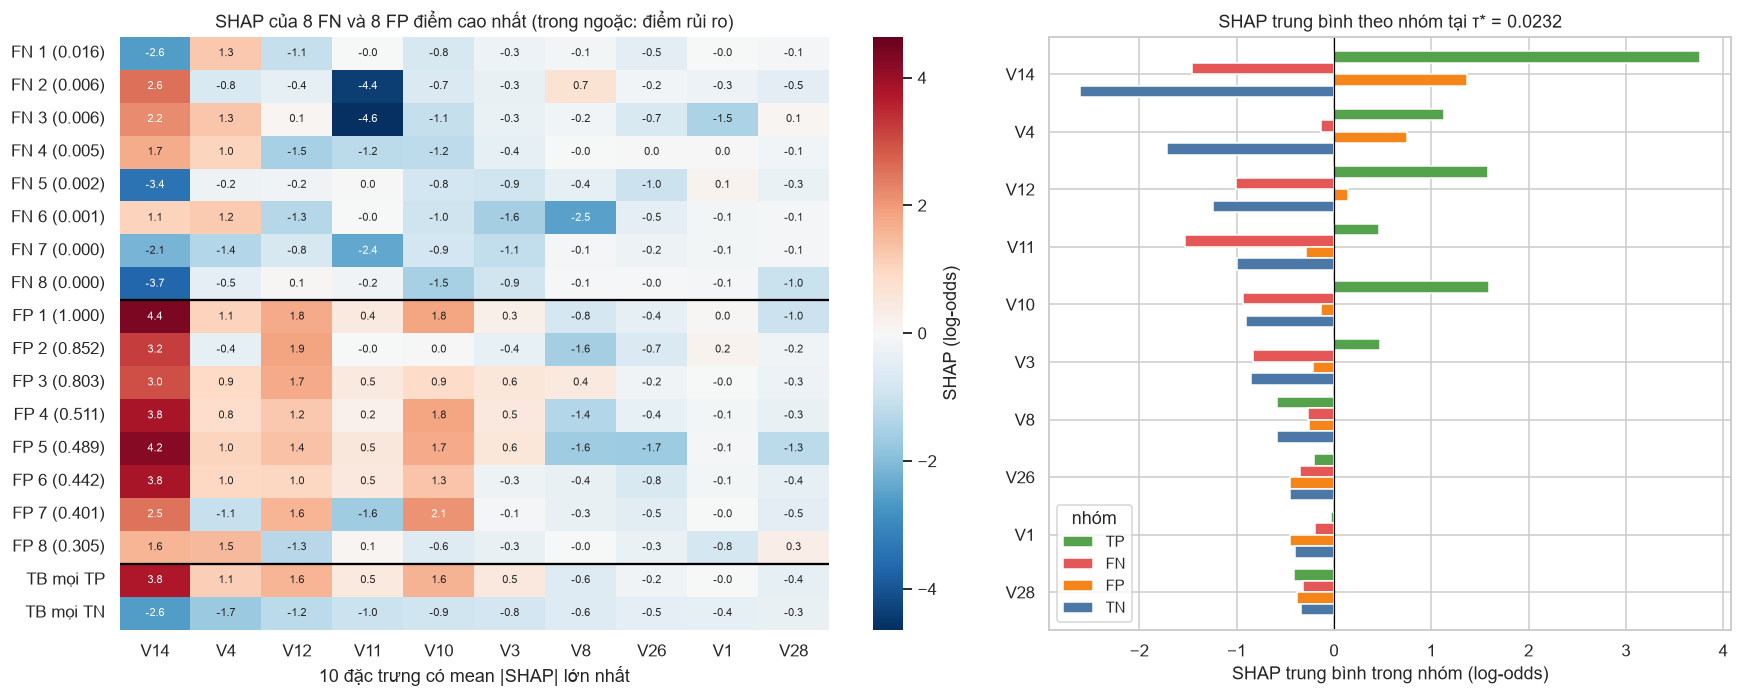

Trung vị giá trị đặc trưng theo nhóm (Amount theo USD, chưa chuẩn hoá):


,TP,FN,FP,TN
V14,-6.92,-0.43,-2.64,0.06
V4,4.45,1.14,3.57,-0.03
V12,-6.07,-0.20,-0.77,0.15
V11,3.94,-0.33,1.14,-0.04
V10,-4.85,-0.14,0.02,-0.09
V3,-5.65,-0.11,-1.91,0.19
V8,0.94,-0.22,-0.09,0.02
V26,0.06,-0.22,-0.13,-0.05
V1,-2.74,-0.10,-0.43,0.03
V28,0.19,0.06,0.04,0.01


In [8]:
# SHAP trung bình của từng nhóm trên 10 đặc trưng quan trọng nhất
TOP = list(xh.index[:10])
tb_nhom = SV[TOP].groupby(nhom).mean().loc[["TP", "FN", "FP", "TN"]]
gia_tri = X_test.reset_index(drop=True)[TOP].groupby(nhom).median().loc[["TP", "FN", "FP", "TN"]]

fig, truc = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})
ax = truc[0]
hang = pd.concat([SV.iloc[fn_idx][TOP].set_axis([f"FN {k + 1} ({diem[i]:.3f})" for k, i in enumerate(fn_idx)]),
                  SV.iloc[fp_idx][TOP].set_axis([f"FP {k + 1} ({diem[i]:.3f})" for k, i in enumerate(fp_idx)]),
                  tb_nhom.loc[["TP", "TN"]].set_axis(["TB mọi TP", "TB mọi TN"])])
gioi_han = np.abs(hang.to_numpy()).max()
sns.heatmap(hang, cmap="RdBu_r", center=0, vmin=-gioi_han, vmax=gioi_han, ax=ax, annot=True, fmt=".1f",
            annot_kws={"fontsize": 7}, cbar_kws={"label": "SHAP (log-odds)"})
ax.axhline(N_LOI, c="black", lw=1.5)
ax.axhline(2 * N_LOI, c="black", lw=1.5)
ax.set_title("SHAP của 8 FN và 8 FP điểm cao nhất (trong ngoặc: điểm rủi ro)")
ax.set_xlabel("10 đặc trưng có mean |SHAP| lớn nhất")

ax = truc[1]
tb_nhom.T.plot.barh(ax=ax, color={"TP": "#54A24B", "FN": "#E45756", "FP": "#F58518", "TN": "#4C78A8"}, width=0.8)
ax.invert_yaxis()
ax.axvline(0, c="black", lw=0.8)
ax.set_xlabel("SHAP trung bình trong nhóm (log-odds)")
ax.set_title(f"SHAP trung bình theo nhóm tại τ* = {TAU_SAO:.4f}")
ax.legend(title="nhóm", fontsize="small")
fig.tight_layout()
plots.save_fig(fig, "07_error_shap.png")
plt.show()

print("Trung vị giá trị đặc trưng theo nhóm (Amount theo USD, chưa chuẩn hoá):")
display(gia_tri.T.round(2))

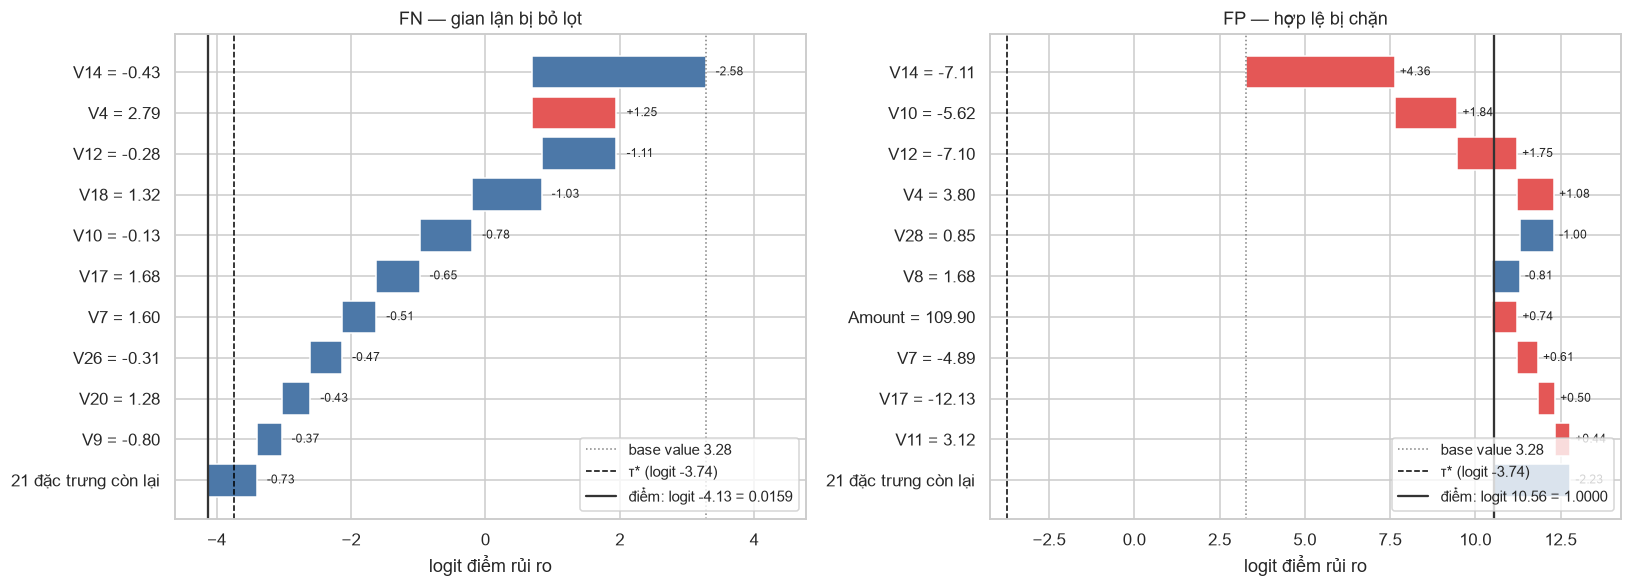

In [9]:
# Waterfall cho FN điểm cao nhất và FP điểm cao nhất
logit_tau = np.log(TAU_SAO / (1 - TAU_SAO))
fig, truc = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, i, loai in ((truc[0], fn_idx[0], "FN — gian lận bị bỏ lọt"), (truc[1], fp_idx[0], "FP — hợp lệ bị chặn")):
    s = SV.iloc[i]
    top = s.reindex(s.abs().sort_values(ascending=False).index[:10])
    con_lai = s.sum() - top.sum()
    muc = pd.concat([top, pd.Series({f"{len(s) - 10} đặc trưng còn lại": con_lai})])
    dau = GOC + np.concatenate([[0], np.cumsum(muc.to_numpy())[:-1]])
    y = np.arange(len(muc))
    ax.barh(y, muc.to_numpy(), left=dau, color=np.where(muc.to_numpy() > 0, "#E45756", "#4C78A8"))
    for yi, (v, l) in enumerate(zip(muc.to_numpy(), dau)):
        ax.text(max(l, l + v) + 0.15, yi, f"{v:+.2f}", va="center", fontsize=8)
    nhan = [f"{k} = {X_test.iloc[i][k]:.2f}" if k in X_test.columns else k for k in muc.index]
    ax.set_yticks(y, nhan)
    ax.invert_yaxis()
    ax.axvline(GOC, c="grey", ls=":", lw=1, label=f"base value {GOC:.2f}")
    ax.axvline(logit_tau, c="black", ls="--", lw=1, label=f"τ* (logit {logit_tau:.2f})")
    ax.axvline(GOC + s.sum(), c="#333333", lw=1.5, label=f"điểm: logit {GOC + s.sum():.2f} = {diem[i]:.4f}")
    dau_cuoi = np.concatenate([dau, dau + muc.to_numpy(), [logit_tau, GOC]])
    ax.set_xlim(dau_cuoi.min() - 0.5, dau_cuoi.max() + 1.5)
    ax.set_xlabel("logit điểm rủi ro")
    ax.set_title(loai)
    ax.legend(fontsize="small", loc="lower right")
fig.tight_layout()
plots.save_fig(fig, "07_waterfall_fn_fp.png")
plt.show()

In [10]:
# Định lượng mẫu hình: giá trị của FN và FP nằm ở đâu so với phân bố của giao dịch hợp lệ (tập train)
hop_le = X_train[y_train == 0]
gian_lan = X_train[y_train == 1]
dac_trung_chinh = list(xh.index[:5])

def ty_le_nam_trong(X_nhom, ref, thap=0.01, cao=0.99):
    # Phần giao dịch có MỌI đặc trưng chính nằm trong khoảng [P1, P99] của nhóm tham chiếu
    lo, hi = ref[dac_trung_chinh].quantile(thap), ref[dac_trung_chinh].quantile(cao)
    return ((X_nhom[dac_trung_chinh] >= lo) & (X_nhom[dac_trung_chinh] <= hi)).all(axis=1).mean()

Xt = X_test.reset_index(drop=True)
print(f"5 đặc trưng chính theo SHAP: {dac_trung_chinh}")
print("Phần giao dịch có cả 5 đặc trưng chính nằm trong [P1, P99] của lớp HỢP LỆ (train):")
for ten in ("TP", "FN", "FP", "TN"):
    print(f"  {ten}: {ty_le_nam_trong(Xt[nhom == ten], hop_le):6.1%}")
print(f"Điểm rủi ro trung vị: FN {np.median(diem[nhom == 'FN']):.5f}, "
      f"FP {np.median(diem[nhom == 'FP']):.3f}, TP {np.median(diem[nhom == 'TP']):.3f}")
print(f"FN có điểm < 0,001 (mô hình gần như chắc chắn là hợp lệ): "
      f"{(diem[nhom == 'FN'] < 0.001).sum()}/{(nhom == 'FN').sum()}")
print(f"Amount trung vị: FP {Xt.loc[nhom == 'FP', 'Amount'].median():.2f}, TN {Xt.loc[nhom == 'TN', 'Amount'].median():.2f}, "
      f"TP {Xt.loc[nhom == 'TP', 'Amount'].median():.2f}, FN {Xt.loc[nhom == 'FN', 'Amount'].median():.2f}")

5 đặc trưng chính theo SHAP: ['V14', 'V4', 'V12', 'V11', 'V10']
Phần giao dịch có cả 5 đặc trưng chính nằm trong [P1, P99] của lớp HỢP LỆ (train):
  TP:   3.9%
  FN:  66.7%


  FP:  36.8%
  TN:  91.7%
Điểm rủi ro trung vị: FN 0.00011, FP 0.065, TP 1.000
FN có điểm < 0,001 (mô hình gần như chắc chắn là hợp lệ): 12/18
Amount trung vị: FP 41.36, TN 21.60, TP 19.04, FN 1.48


**Nhận xét T-33 — mẫu hình chung: mô hình là một bộ dò theo "chữ ký" V14 / V12 / V10 / V4. Nó
sai khi nhãn không khớp với chữ ký đó.**

**FN — gian lận không mang chữ ký.**

- **12/18 FN có điểm dưới 0,001**, trung vị 0,00011. Mô hình không "suýt bắt được" chúng mà gần
  như chắc chắn chúng hợp lệ.
- **66,7% FN có cả 5 đặc trưng chính nằm trong khoảng P1–P99 của lớp hợp lệ**, so với 91,7% ở TN
  và chỉ 3,9% ở TP. Trung vị V14 của FN là −0,43, gần với TN (0,06) hơn là TP (−6,92). Trong không
  gian 31 đặc trưng, các vụ này trông như giao dịch bình thường.
- **Ở các FN điểm cao nhất, tín hiệu bị phủ quyết.** FN 2, 3, 4 và 6 có V14 đẩy điểm **lên**
  (+1,1 tới +2,6), nhưng bị V11 (tới −4,6), V12, V10 hoặc V8 kéo xuống mạnh hơn. Chữ ký chỉ có
  một phần, và phần thiếu quyết định kết quả.
- **Số tiền rất nhỏ:** trung vị `Amount` của FN là **1,48 USD**, so với 19,04 ở TP. `Amount` là một
  trong hai cột không qua PCA, nên đây là quan sát nói được. Nhưng nó chỉ là quan sát trên 18 ca,
  không phải kết luận về một kiểu gian lận.

**FP — giao dịch hợp lệ mang chữ ký gian lận.**

- **Cả 8 FP điểm cao nhất đều có V14 đẩy điểm lên** (+1,6 tới +4,4), và phần lớn có thêm V10, V12
  cùng chiều. Trên heatmap, các hàng FP gần như trùng với hàng "trung bình mọi TP".
- **FP điểm cao nhất (điểm 1,0000)** có V14 = −7,11, V10 = −5,62, V12 = −7,10, tức nằm ngay giữa
  vùng của gian lận. Hoặc đây là một giao dịch hợp lệ bất thường thật, hoặc nhãn bị sai (gian lận
  không được báo cáo). Dữ liệu không cho phép phân biệt hai khả năng này.
- 36,8% FP vẫn nằm trong khoảng P1–P99 của lớp hợp lệ ở cả 5 đặc trưng chính. Nhóm này bị đẩy qua
  ngưỡng bởi nhiều đóng góp nhỏ cộng dồn, không phải một tín hiệu mạnh. Trung vị `Amount` của FP là
  41,36 USD, gấp đôi TN (21,60).

**Hệ quả.** Hai loại lỗi đều là trường hợp **đặc trưng không mang đủ thông tin để phân biệt**, không
phải mô hình học sai. Điều này khớp với kết luận của giai đoạn 4 ("trần nằm ở dữ liệu, không nằm ở
siêu tham số"). Nó cũng giải thích bảng T-30: muốn bắt các FN này phải hạ ngưỡng xuống vùng mà
hàng trăm giao dịch hợp lệ có cùng điểm (τ cho recall ≥ 90% sinh 720 FP). Cải thiện thật sự cần
**đặc trưng mới**, ví dụ lịch sử của thẻ hay tần suất giao dịch gần đây, mà bộ dữ liệu này không có.

**Câu chốt bắt buộc:** *V1–V28 là thành phần chính sau PCA nên các mẫu hình trên chỉ mô tả
**hình dạng** của lỗi trong không gian đặc trưng ("FN có V14 gần 0"). Chúng không được diễn giải
thành nguyên nhân nghiệp vụ ("FN là loại gian lận X"), vì không ai ngoài bên phát hành dữ liệu
biết V14 ứng với biến gốc nào.*

---
## 4. Tổng kết

| Việc | Kết quả | Trạng thái |
|---|---|---|
| T-32 | SHAP chính xác trên 56.746 giao dịch (sai số cộng 2·10⁻⁵). Top 5: V14, V4, V12, V11, V10 = 46%. So với T-15: Spearman 0,42–0,43; V17 hạng 1 theo Cohen's d nhưng hạng 24 theo SHAP do thừa thông tin → `reports/shap_ranking.csv` | ✅ |
| T-33 | 8 FN + 8 FP điểm cao nhất → `reports/error_analysis.csv`. FN không mang chữ ký (12/18 có điểm < 0,001; 67% nằm trong vùng của lớp hợp lệ); FP mang đủ chữ ký. Có câu chốt về PCA | ✅ |

**Mang sang giai đoạn 6:** `models/explainer.joblib` là `TreeExplainer` của bước `clf` trong pipeline,
nhận đầu vào **sau** bước tiền xử lý (`pipeline[:-1].transform`). Xếp hạng `mean|SHAP|` cho
`metrics.json` lấy từ `reports/shap_ranking.csv`. Endpoint `/explain` (AC-A4) phải khớp với SHAP
của notebook này.